<a href="https://colab.research.google.com/github/hersh-4/CSC-442-Group-Project/blob/main/CSC_442_HW_6_Query_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
merged_dataset = pd.read_csv('merged_dataset.csv')

# Display first few rows
merged_dataset.head()


,state_name,county_fips,county_name,votes_gop,votes_dem,total_votes,diff,per_gop,per_dem,per_point_diff,...,Annual Healthcare,Annual Other Necessities,Annual Childcare,Annual Taxes,Annual Total,median_family_income,num_counties_in_st,st_cost_rank,st_med_aff_rank,st_income_rank
0,Alabama,1001,Autauga County,20484,7439,28190,13045.0,0.726641,0.263888,0.462753,...,15542.13558,8851.80505,10535.61214,13662.01629,93477.5104,83452.0,67.0,8.0,48.0,11.0
1,Alabama,1003,Baldwin County,95798,24934,121808,70864.0,0.786467,0.204699,0.581768,...,14644.38907,9746.87133,10351.86510,14544.30292,97116.7975,92918.0,67.0,2.0,59.0,4.0
2,Alabama,1005,Barbour County,5606,4158,9832,1448.0,0.570179,0.422905,0.147274,...,14356.61277,7070.95930,8055.20472,9870.87344,77551.0166,60474.0,67.0,63.0,19.0,55.0
3,Alabama,1007,Bibb County,7572,1619,9241,5953.0,0.819392,0.175197,0.644194,...,14823.93821,7025.80685,11188.32950,11808.59579,85717.8629,67222.0,67.0,18.0,20.0,39.0
4,Alabama,1009,Blount County,25354,2576,28115,22778.0,0.901796,0.091624,0.810173,...,14823.93821,6697.65267,11567.09626,11478.51394,84304.6712,76388.0,67.0,24.0,46.0,18.0


Data Preprocessing, Only keeping data relevant to analysis


In [ ]:
# Define relevant economic indicators as features
features = ['Annual Housing', 'Annual Food', 'Annual Transportation',
            'Annual Healthcare', 'Annual Other Necessities', 'Annual Childcare',
            'Annual Taxes']
# Define target variable
target = 'per_gop'

# Drop missing values and unneeded columns for this analysis
df = merged_dataset[features + [target]].dropna()

# Check dataset size after dropping unneeded columns
print(f"Dataset size after preprocessing: {df.shape}")

Dataset size after preprocessing: (3104, 8)


# **Exploratory Data Analysis (EDA)**

Scatter Plot: Annual Other Necessities vs. GOP Vote Share

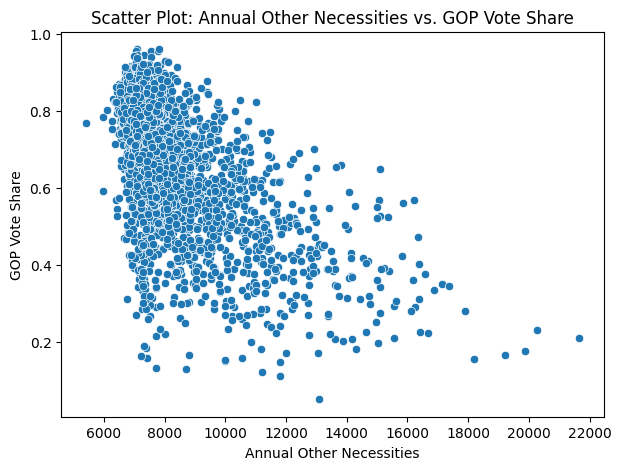

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual Other Necessities', y=target)
plt.xlabel("Annual Other Necessities")
plt.ylabel("GOP Vote Share")
plt.title("Scatter Plot: Annual Other Necessities vs. GOP Vote Share")
plt.show()

Scatter Plot: Annual Taxes vs. GOP Vote Share

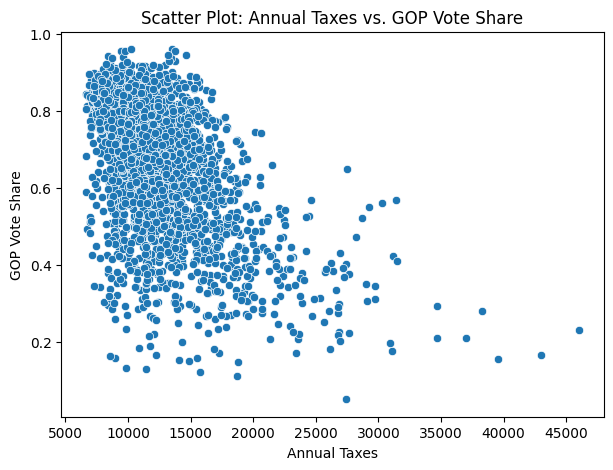

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual Taxes', y=target)
plt.xlabel("Annual Taxes")
plt.ylabel("GOP Vote Share")
plt.title("Scatter Plot: Annual Taxes vs. GOP Vote Share")
plt.show()

Scatter Plot: Annual Food vs. GOP Vote Share

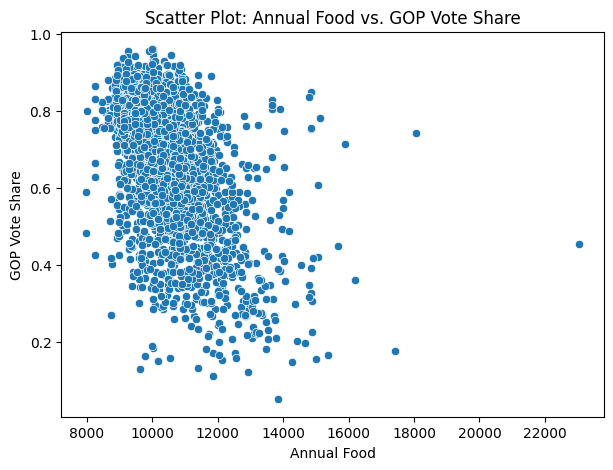

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual Food', y=target)
plt.xlabel("Annual Food")
plt.ylabel("GOP Vote Share")
plt.title("Scatter Plot: Annual Food vs. GOP Vote Share")
plt.show()

Scatter Plot: Annual Healthcare vs. GOP Vote Share

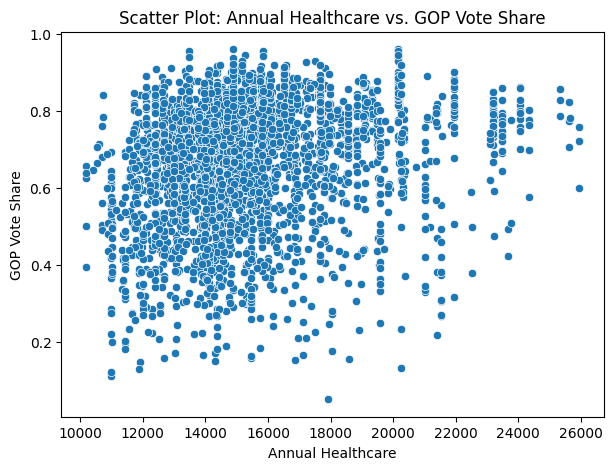

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual Healthcare', y=target)
plt.xlabel("Annual Healthcare")
plt.ylabel("GOP Vote Share")
plt.title("Scatter Plot: Annual Healthcare vs. GOP Vote Share")
plt.show()

# **Splits the Data into Training and Testing Sets**

Split data into training and testing sets

In [ ]:
X = df[features]  # Independent variables
y = []            # Target variable

# Discretizes the y target variable with a 1 indicating a Republican victory and
# a 0 indicating a Democrat victory in that county.
for value in df[target]:
  y.append(1) if value > 0.5 else y.append(0)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (2483, 7)
Testing data size: (621, 7)


# Build & Evaluate K-Nearest Neighbors Model

Train KNN Model

In [ ]:
# Initialize KNN model
knnModel = KNeighborsClassifier(n_neighbors=5)

# Train model on training data
knnModel.fit(X_train, y_train)

# Predict on test data
y_pred = knnModel.predict(X_test)

# Model Evaluation

Calculate Performance Metrics

In [ ]:
# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print evaluation results
print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Performance:
Mean Absolute Error (MAE): 0.1176
Mean Squared Error (MSE): 0.1176
Root Mean Squared Error (RMSE): 0.3429
R² Score: 0.1877


# Cross-Validation for Model Robustness

In [ ]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(knnModel, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean Cross-Validation R² Score: {cv_scores.mean():.4f}")

Cross-Validation R² Scores: [-0.42915749  0.17978787 -0.035       0.07589286  0.09253133]
Mean Cross-Validation R² Score: -0.0232
